In [ ]:


"""
U-Net Denoiser — NoisyOffice

Requirements:
    pip install pytorch-msssim opencv-python-headless matplotlib pillow
"""

# ── 0. DEPENDENCIES ───────────────────────────────────────────────────────────

import os
import sys
import glob
import random
import shutil
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

In [ ]:
!pip install pytorch-msssim

In [ ]:

# ── 1. DEVICE ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ── 2. GOOGLE DRIVE MOUNT + PATHS ─────────────────────────────────────────────
# UPDATE DRIVE_ROOT to wherever your NoisyOffice folder lives in Drive

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — skipping Drive mount')

DRIVE_ROOT = '/content/drive/MyDrive/OCR/Dataset'   # <-- UPDATE THIS

CLEAN_DIR  = os.path.join(DRIVE_ROOT, 'clean_images_grayscale')
NOISY_DIR  = os.path.join(DRIVE_ROOT, 'simulated_noisy_images_grayscale')

for d, name in [(CLEAN_DIR, 'clean'), (NOISY_DIR, 'noisy')]:
    files = glob.glob(os.path.join(d, '*'))
    print(f'{name}: {len(files)} files at {d}')
    if len(files) == 0:
        print(f'  WARNING: no files found — check DRIVE_ROOT path')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
clean: 54 files at /content/drive/MyDrive/OCR/Dataset/clean_images_grayscale
noisy: 216 files at /content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale


In [ ]:
class NoisyOfficeDataset(Dataset):
    def __init__(self, clean_dir, noisy_dir, patch_size=256, augment=True):
        self.patch_size = patch_size
        self.augment = augment

        clean_files = sorted(glob.glob(os.path.join(clean_dir, '*')))
        noisy_files = sorted(glob.glob(os.path.join(noisy_dir, '*')))

        self.pairs = []

        # Build mapping: each clean image -> all matching noisy versions
        for c in clean_files:
            cname = os.path.basename(c)
            stem = os.path.splitext(cname)[0]

            # Example: FontLre_Clean_TE -> ['FontLre', 'Clean', 'TE']
            parts = stem.split("_")
            if len(parts) != 3:
                continue

            prefix = parts[0]   # FontLre
            suffix = parts[2]   # TE

            for n in noisy_files:
                nname = os.path.basename(n)
                nstem = os.path.splitext(nname)[0]
                nparts = nstem.split("_")

                # Example: FontLre_Noisec_TE -> ['FontLre', 'Noisec', 'TE']
                if len(nparts) != 3:
                    continue

                if nparts[0] == prefix and nparts[2] == suffix:
                    self.pairs.append((c, n))

        print(f"Total pairs: {len(self.pairs)}")
        assert len(self.pairs) > 0, "No pairs found!"

    def __len__(self):
        return len(self.pairs)

    def _load_gray(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(path)
        return img.astype(np.float32) / 255.0

    def _random_crop(self, clean, noisy):
        h, w = clean.shape
        p = self.patch_size

        if h < p or w < p:
            clean = cv2.resize(clean, (p, p))
            noisy = cv2.resize(noisy, (p, p))
            return clean, noisy

        y = random.randint(0, h - p)
        x = random.randint(0, w - p)
        return clean[y:y+p, x:x+p], noisy[y:y+p, x:x+p]

    def _augment(self, clean, noisy):
        if random.random() > 0.5:
            clean = np.fliplr(clean).copy()
            noisy = np.fliplr(noisy).copy()

        if random.random() > 0.5:
            clean = np.flipud(clean).copy()
            noisy = np.flipud(noisy).copy()

        k = random.randint(0, 3)
        clean = np.rot90(clean, k).copy()
        noisy = np.rot90(noisy, k).copy()

        return clean, noisy

    def __getitem__(self, idx):
        clean_path, noisy_path = self.pairs[idx]

        clean = self._load_gray(clean_path)
        noisy = self._load_gray(noisy_path)

        if clean.shape != noisy.shape:
            noisy = cv2.resize(noisy, (clean.shape[1], clean.shape[0]))

        clean, noisy = self._random_crop(clean, noisy)

        if self.augment:
            clean, noisy = self._augment(clean, noisy)

        return (
            torch.from_numpy(noisy).unsqueeze(0),
            torch.from_numpy(clean).unsqueeze(0),
        )

In [ ]:
dataset = NoisyOfficeDataset(CLEAN_DIR, NOISY_DIR)
print(dataset.pairs[:10])

Total pairs: 216
[('/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png', '/content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale/FontLre_Noisec_TE.png'), ('/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png', '/content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale/FontLre_Noisef_TE.png'), ('/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png', '/content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale/FontLre_Noisep_TE.png'), ('/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TE.png', '/content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale/FontLre_Noisew_TE.png'), ('/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TR.png', '/content/drive/MyDrive/OCR/Dataset/simulated_noisy_images_grayscale/FontLre_Noisec_TR.png'), ('/content/drive/MyDrive/OCR/Dataset/clean_images_grayscale/FontLre_Clean_TR.png', '/content/driv

In [ ]:
def build_dataloaders(clean_dir, noisy_dir, patch_size=256,
                      batch_size=8, val_split=0.1):
    full_ds = NoisyOfficeDataset(
        clean_dir=clean_dir,
        noisy_dir=noisy_dir,
        patch_size=patch_size,
        augment=True
    )

    val_size = max(1, int(len(full_ds) * val_split))
    train_size = len(full_ds) - val_size

    train_ds, val_ds = random_split(
        full_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=max(1, batch_size // 2),
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)}")
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

    return train_loader, val_loader

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    """Two conv layers with GroupNorm + ReLU."""
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        g1 = min(groups, out_ch)
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(g1, out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(g1, out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """Upsample + concat skip + ConvBlock."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=1)
        )
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        # handle odd-size mismatch
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNetDenoiser(nn.Module):
    """
    Residual U-Net:
    model predicts noise, output = input - noise
    """
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        b = base_ch

        self.enc1 = ConvBlock(in_ch, b)
        self.enc2 = ConvBlock(b, b * 2)
        self.enc3 = ConvBlock(b * 2, b * 4)
        self.neck = ConvBlock(b * 4, b * 8)

        self.pool = nn.MaxPool2d(2)

        self.dec3 = UpBlock(b * 8, b * 4, b * 4)
        self.dec2 = UpBlock(b * 4, b * 2, b * 2)
        self.dec1 = UpBlock(b * 2, b, b)

        self.out_conv = nn.Conv2d(b, out_ch, kernel_size=1)

    def forward(self, x):
        inp = x

        e1 = self.enc1(x)              # b
        e2 = self.enc2(self.pool(e1))  # 2b
        e3 = self.enc3(self.pool(e2))  # 4b
        n  = self.neck(self.pool(e3))  # 8b

        d3 = self.dec3(n, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        pred_noise = self.out_conv(d1)
        clean = inp - pred_noise

        # keep output in valid image range
        clean = torch.clamp(clean, 0.0, 1.0)
        return clean

In [ ]:
def build_model(device):
    model = UNetDenoiser(in_ch=1, out_ch=1, base_ch=32).to(device)

    total = sum(p.numel() for p in model.parameters())
    print(f'Model parameters: {total:,}')

    with torch.no_grad():
        dummy = torch.zeros(1, 1, 128, 128).to(device)
        out = model(dummy)
        print(f'Sanity check — input: {dummy.shape} | output: {out.shape}')

    return model

In [ ]:
import os

print("CLEAN")
for f in sorted(os.listdir(CLEAN_DIR))[:15]:
    print(f)

print("\nNOISY")
for f in sorted(os.listdir(NOISY_DIR))[:15]:
    print(f)

CLEAN
FontLre_Clean_TE.png
FontLre_Clean_TR.png
FontLre_Clean_VA.png
FontLrm_Clean_TE.png
FontLrm_Clean_TR.png
FontLrm_Clean_VA.png
FontLse_Clean_TE.png
FontLse_Clean_TR.png
FontLse_Clean_VA.png
FontLsm_Clean_TE.png
FontLsm_Clean_TR.png
FontLsm_Clean_VA.png
FontLte_Clean_TE.png
FontLte_Clean_TR.png
FontLte_Clean_VA.png

NOISY
FontLre_Noisec_TE.png
FontLre_Noisec_TR.png
FontLre_Noisec_VA.png
FontLre_Noisef_TE.png
FontLre_Noisef_TR.png
FontLre_Noisef_VA.png
FontLre_Noisep_TE.png
FontLre_Noisep_TR.png
FontLre_Noisep_VA.png
FontLre_Noisew_TE.png
FontLre_Noisew_TR.png
FontLre_Noisew_VA.png
FontLrm_Noisec_TE.png
FontLrm_Noisec_TR.png
FontLrm_Noisec_VA.png


In [ ]:

# ── 5. LOSS + METRICS ─────────────────────────────────────────────────────────

mse_fn = nn.MSELoss()

def combined_loss(pred, target):
    """0.5 * MSE + 0.5 * (1 - SSIM) — balances pixel accuracy and structure."""
    l_mse  = mse_fn(pred, target)
    l_ssim = 1.0 - ssim(pred, target, data_range=1.0, size_average=True)
    return 0.5 * l_mse + 0.5 * l_ssim

def psnr(pred, target):
    """Peak Signal-to-Noise Ratio. Target: >28 dB for document denoising."""
    mse = mse_fn(pred, target).item()
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))



In [ ]:

# ── 6. TRAINING LOOP ──────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        pred = model(noisy)
        loss = combined_loss(pred, clean)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = total_psnr = total_ssim_val = 0.0
    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        pred            = model(noisy)
        total_loss     += combined_loss(pred, clean).item()
        total_psnr     += psnr(pred, clean)
        total_ssim_val += ssim(pred, clean, data_range=1.0, size_average=True).item()
    n = len(loader)
    return total_loss / n, total_psnr / n, total_ssim_val / n


def train(model, train_loader, val_loader, device,
          epochs=50, lr=1e-3, save_path='unet_denoiser_best.pth'):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    best_loss = float('inf')
    history   = {'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': []}

    for epoch in range(1, epochs + 1):
        train_loss             = train_epoch(model, train_loader, optimizer, device)
        val_loss, val_p, val_s = validate(model, val_loader, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_p)
        history['val_ssim'].append(val_s)

        print(f'Epoch {epoch:02d}/{epochs} | '
              f'Train: {train_loss:.4f} | '
              f'Val: {val_loss:.4f} | '
              f'PSNR: {val_p:.2f} dB | '
              f'SSIM: {val_s:.4f}')

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save({
                'epoch':            epoch,
                'model_state_dict': model.state_dict(),
                'val_loss':         val_loss,
                'val_psnr':         val_p,
                'val_ssim':         val_s,
            }, save_path)
            print(f'  --> Saved best model (val_loss={val_loss:.4f})')

    print(f'\nTraining complete. Best val loss: {best_loss:.4f}')
    return history


def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'],   label='val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['val_psnr'])
    axes[1].set_title('Val PSNR (dB) — higher is better')
    axes[1].set_xlabel('Epoch')
    axes[1].grid(True)

    axes[2].plot(history['val_ssim'])
    axes[2].set_title('Val SSIM — higher is better')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=120)
    plt.show()
    print('Training curves saved to training_curves.png')


In [ ]:


# ── 7. INFERENCE ──────────────────────────────────────────────────────────────

@torch.no_grad()
def denoise_image(model, image_path_or_array, device):
    """
    Denoise a full document image of any size.

    Pads to a multiple of 8 before inference (U-Net has 3 pooling steps),
    then crops back to original size.

    Args:
        model:                trained U-Net
        image_path_or_array:  file path string OR numpy array (grayscale uint8)
        device:               torch device

    Returns:
        denoised numpy array (H, W), uint8, values 0-255
    """
    model.eval()

    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f'Cannot read image: {image_path_or_array}')
    else:
        img = image_path_or_array
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w     = img.shape
    img_norm = img.astype(np.float32) / 255.0

    # Pad to multiple of 8
    pad_h      = (8 - h % 8) % 8
    pad_w      = (8 - w % 8) % 8
    img_padded = np.pad(img_norm, ((0, pad_h), (0, pad_w)), mode='reflect')

    tensor = torch.from_numpy(img_padded).unsqueeze(0).unsqueeze(0).to(device)
    output = model(tensor).squeeze().cpu().numpy()

    # Crop back to original size
    output = output[:h, :w]
    return (output * 255).clip(0, 255).astype(np.uint8)



In [ ]:

def visualise_denoising(model, dataset, device, n_samples=4):
    """Show noisy / denoised / clean side by side for n_samples."""
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    for ax, col in zip(axes[0], ['Noisy input', 'Denoised (U-Net)', 'Clean target']):
        ax.set_title(col, fontsize=11)

    for i in range(n_samples):
        noisy, clean = dataset[i]
        with torch.no_grad():
            pred = model(noisy.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        p = psnr(
            model(noisy.unsqueeze(0).to(device)),
            clean.unsqueeze(0).to(device)
        )
        for j, img in enumerate([noisy.squeeze().numpy(), pred,
                                  clean.squeeze().numpy()]):
            axes[i][j].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[i][j].axis('off')
        axes[i][1].set_xlabel(f'PSNR: {p:.1f} dB', fontsize=9)

    plt.tight_layout()
    plt.savefig('denoising_samples.png', dpi=120)
    plt.show()
    print('Samples saved to denoising_samples.png')



Total pairs: 216
Train size: 195 | Val size: 21
Train batches: 25 | Val batches: 6


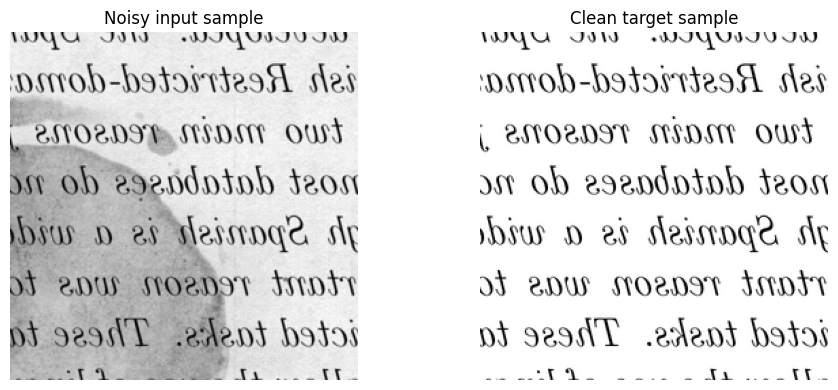

Sample pair saved to sample_pair.png
Model parameters: 1,797,409
Sanity check — input: torch.Size([1, 1, 128, 128]) | output: torch.Size([1, 1, 128, 128])
Epoch 01/50 | Train: 0.0339 | Val: 0.0095 | PSNR: 27.26 dB | SSIM: 0.9830
  --> Saved best model (val_loss=0.0095)
Epoch 02/50 | Train: 0.0082 | Val: 0.0060 | PSNR: 29.21 dB | SSIM: 0.9893
  --> Saved best model (val_loss=0.0060)
Epoch 03/50 | Train: 0.0062 | Val: 0.0057 | PSNR: 29.14 dB | SSIM: 0.9897
  --> Saved best model (val_loss=0.0057)
Epoch 04/50 | Train: 0.0054 | Val: 0.0049 | PSNR: 30.45 dB | SSIM: 0.9911
  --> Saved best model (val_loss=0.0049)
Epoch 05/50 | Train: 0.0052 | Val: 0.0072 | PSNR: 29.11 dB | SSIM: 0.9869
Epoch 06/50 | Train: 0.0047 | Val: 0.0080 | PSNR: 29.39 dB | SSIM: 0.9853
Epoch 07/50 | Train: 0.0047 | Val: 0.0045 | PSNR: 30.79 dB | SSIM: 0.9919
  --> Saved best model (val_loss=0.0045)
Epoch 08/50 | Train: 0.0046 | Val: 0.0067 | PSNR: 30.01 dB | SSIM: 0.9877
Epoch 09/50 | Train: 0.0045 | Val: 0.0046 | PSNR

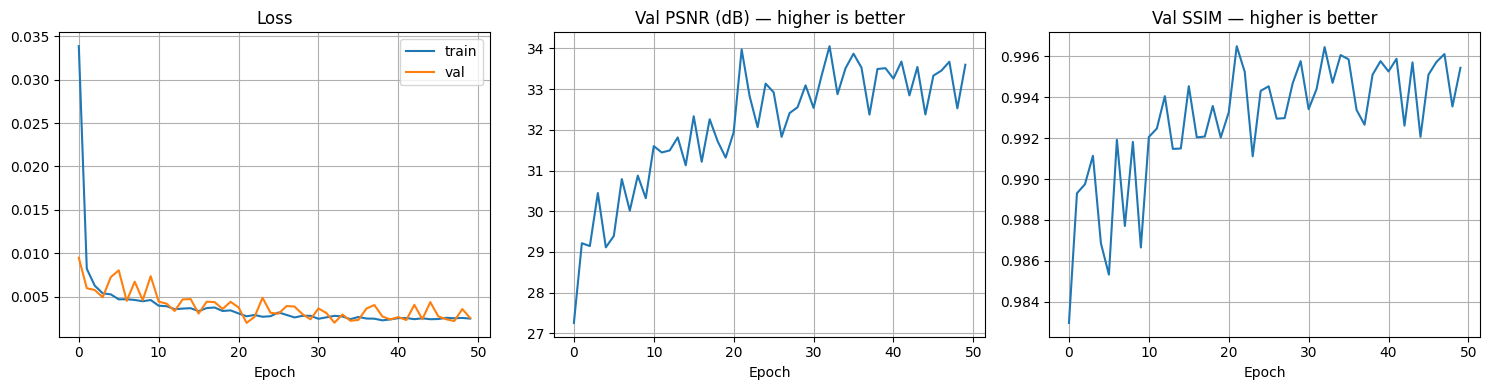

Training curves saved to training_curves.png

Loaded best model from epoch 22
Val PSNR: 33.98 dB | Val SSIM: 0.9965


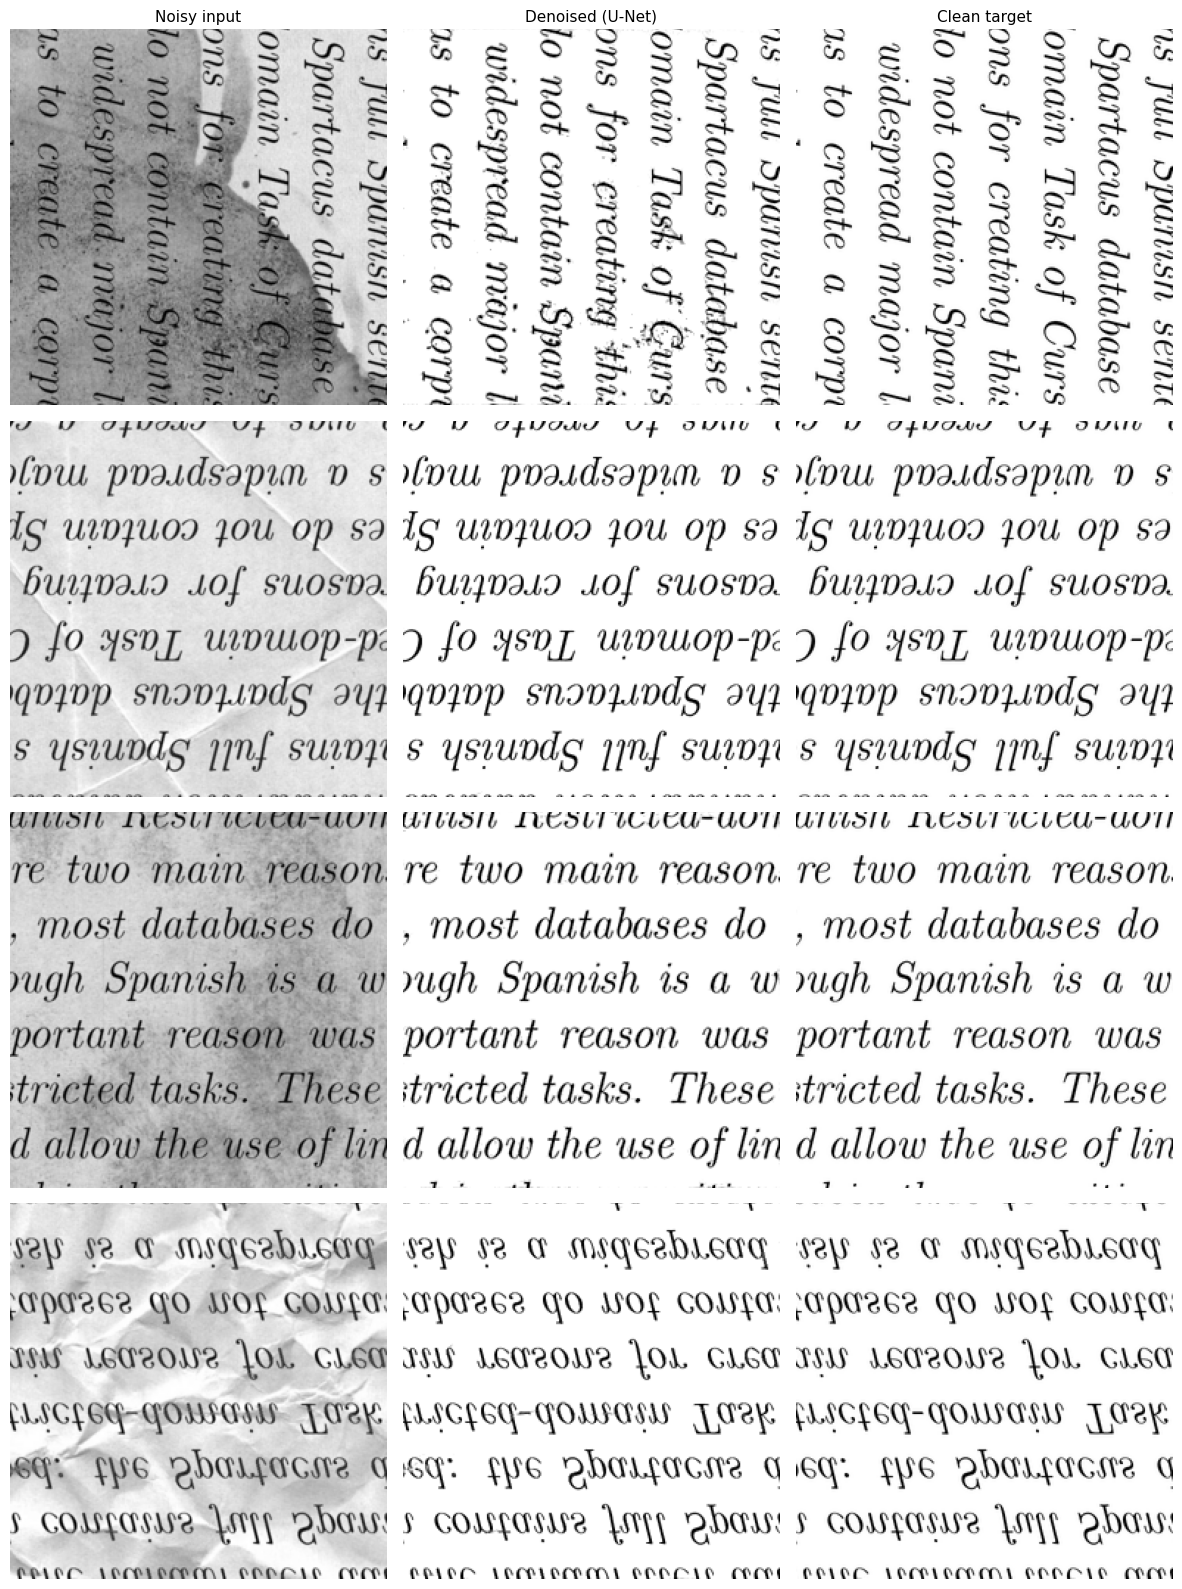

Samples saved to denoising_samples.png
Weights saved to Drive: /content/drive/MyDrive/OCR/Dataset/unet_denoiser_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. Use denoise_image(model, image_path, device) in your OCR pipeline.


In [ ]:

# ── 8. MAIN ───────────────────────────────────────────────────────────────────

if __name__ == '__main__':

    SAVE_PATH  = 'unet_denoiser_best.pth'
    EPOCHS     = 50
    BATCH_SIZE = 8
    PATCH_SIZE = 256

    # Build dataloaders


    train_loader, val_loader = build_dataloaders(
        CLEAN_DIR, NOISY_DIR,
        patch_size=PATCH_SIZE,
        batch_size=BATCH_SIZE,
    )

    # Visualise a sample pair before training
    full_ds    = train_loader.dataset.dataset
    noisy_s, clean_s = full_ds[0]
    fig, ax    = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(noisy_s.squeeze().numpy(), cmap='gray')
    ax[0].set_title('Noisy input sample')
    ax[0].axis('off')
    ax[1].imshow(clean_s.squeeze().numpy(), cmap='gray')
    ax[1].set_title('Clean target sample')
    ax[1].axis('off')
    plt.tight_layout()
    plt.savefig('sample_pair.png', dpi=100)
    plt.show()
    print('Sample pair saved to sample_pair.png')

    # Build model
    model = build_model(device)

    # Train
    history = train(
        model, train_loader, val_loader, device,
        epochs=EPOCHS, save_path=SAVE_PATH
    )

    # Plot curves
    plot_history(history)

    # Load best weights
    ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
    # Load best weights

    model.load_state_dict(ckpt['model_state_dict'])
    print(f"\nLoaded best model from epoch {ckpt['epoch']}")
    print(f"Val PSNR: {ckpt['val_psnr']:.2f} dB | Val SSIM: {ckpt['val_ssim']:.4f}")

    # Visualise results
    visualise_denoising(model, full_ds, device, n_samples=4)

    # Save to Drive
    if IN_COLAB:
        drive_save = os.path.join(DRIVE_ROOT, 'unet_denoiser_best.pth')
        shutil.copy(SAVE_PATH, drive_save)
        print(f'Weights saved to Drive: {drive_save}')

        from google.colab import files
        files.download(SAVE_PATH)

    print('\nDone. Use denoise_image(model, image_path, device) in your OCR pipeline.')